In [1]:
import numpy as np
import random
from typing import Literal

In [2]:
class Env:
    """
    An environment to run the algorithms

    Parameters
    ----------
    means: list[float]
        The base means
    arm_algorithm: Literal['top']

    Attributes
    ----------
    means: list[float]
        The base means
    algorithm: Literal['top']
        The algorithm to use for the arms.
    pull_history: list[int]
        The history of the arms pulled.
    regret_history: list[float] 
        The history of the regret.
    """
    def __init__(self, means: list[float], arm_algorithm: Literal['top']):
        self.means = means
        self.algorithm = arm_algorithm
        self.pull_history = []
        self.regret_history = []
    def pull_arm(self, arm: int):
        """
        Pull the selected arm, using a bernoulli distribution with the mean of the arm as the probability of success.

        Parameters
        ----------
        arm: int
            The arm to pull.
        
        Returns
        -------
        float
            The reward from the arm.
        """
        self.pull_history.append(arm)
        self.regret_history.append(max(self.means) - self.means[arm])
        return 1 if random.random() < self.means[arm] else 0

In [3]:
def epsilon_greedy(K: int, total_steps: int, epsilon: float, env: Env):
    """
    The epsilon-greedy algorithm

    Parameters
    ----------
    K: int
        Number of arms
    total_steps: int
        Number of rounds to play
    epsilon: float
        Probability of exploration (0 <= epsilon <= 1)
    env: Env
        The environment to run the algorithm in.

    Returns
    -------
    values: list[float]
        The estimated values of each arm after the algorithm has run.
    counts: list[int]
        The number of times each arm was pulled.
    total_reward: float
        The total reward accumulated over all rounds.
    """
    # Initialize counts and estimated values for each arm
    counts = [0] * K
    values = [0.0] * K
    total_reward = 0
    
    for step in range(total_steps):
        # Choose arm
        if random.random() < epsilon:
            # Explore: choose a random arm
            chosen_arm = random.randint(0, K - 1)
        else:
            # Exploit: choose the best known arm (break ties randomly)
            max_val = max(values)
            best_arms = [i for i, val in enumerate(values) if val == max_val]
            chosen_arm = random.choice(best_arms)
        
        # Pull the chosen arm and observe reward
        reward = env.pull_arm(chosen_arm)
        total_reward += reward
        
        # Update empirical average formula: Q_t(a) = Q_{t-1}(a) + (R_t - Q_{t-1}(a)) / N_t(a)
        counts[chosen_arm] += 1
        n = counts[chosen_arm]
        values[chosen_arm] += (reward - values[chosen_arm]) / n
        
    return values, counts, total_reward

In [4]:
def epsilon_greedy_decay(K, total_steps, epsilon_start, epsilon_min, decay_rate, pull_arm):
    """
    Run the epsilon-greedy algorithm with decaying epsilon.

    Parameters
    ----------
    K: (int)
        Number of arms
    total_steps: (int)
        Number of rounds to play
    epsilon_start: (float)
        Initial exploration probability (typically 1.0)
    epsilon_min: (float)
        Minimum exploration probability (typically 0.01 to 0.1)
    decay_rate: (float)
        Multiplicative factor to decrease epsilon each step (typically 0.99 to 0.999)
    pull_arm: (function)
        Function that takes an arm index and returns a reward
    
    Returns
    -------
    values: list[float]
        The estimated values of each arm after the algorithm has run.
    counts: list[int]
        The number of times each arm was pulled.
    total_reward: float
        The total reward accumulated over all rounds.
    epsilon_history: list[float]
        The history of epsilon values over time.
    """
    # Initialize counts and estimated values for each arm
    counts = [0] * K
    values = [0.0] * K
    total_reward = 0
    epsilon = epsilon_start
    
    # Track epsilon values over time for debugging/plotting
    epsilon_history = []
    
    for step in range(total_steps):
        epsilon_history.append(epsilon)
        
        # Choose arm
        if random.random() < epsilon:
            # Explore: choose a random arm
            chosen_arm = random.randint(0, K - 1)
        else:
            # Exploit: choose the best known arm (break ties randomly)
            max_val = max(values)
            best_arms = [i for i, val in enumerate(values) if val == max_val]
            chosen_arm = random.choice(best_arms)
        
        # Pull the chosen arm and observe reward
        reward = pull_arm(chosen_arm)
        total_reward += reward
        
        # Update empirical average
        counts[chosen_arm] += 1
        n = counts[chosen_arm]
        values[chosen_arm] += (reward - values[chosen_arm]) / n
        
        # Decay epsilon
        epsilon = max(epsilon_min, epsilon * decay_rate)
        
    return values, counts, total_reward, epsilon_history

In [25]:
import math

def ucb1(K: int, total_steps: int, env: Env):
    """
    Run the UCB1 algorithm.

    Parameters
    ----------
    K: (int)
        Number of arms
    total_steps: (int)
        Number of rounds to play
    env: (Env)
        Environment object with pull_arm method
    
    Returns
    -------
    values: list[float]
        The estimated values of each arm after the algorithm has run.
    counts: list[int]
        The number of times each arm was pulled.
    total_reward: float
        The total reward accumulated over all rounds.
    """
    counts = [0] * K
    values = [0.0] * K
    total_reward = 0
    
    # Try each arm once to initialize
    for arm in range(K):
        reward = env.pull_arm(arm)
        total_reward += reward
        counts[arm] = 1
        values[arm] = reward
        
    for step in range(K, total_steps):
        # Calculate UCB values for each arm
        ucb_values = []
        for arm in range(K):
            # step represents the total number of plays 't'
            bonus = math.sqrt((math.log(step)) / counts[arm])
            ucb_values.append(values[arm] + bonus)
            
        # Select the arm with the highest UCB value
        max_ucb = max(ucb_values)
        best_arms = [i for i, val in enumerate(ucb_values) if val == max_ucb]
        chosen_arm = random.choice(best_arms)
        
        # Pull arm and update
        reward = env.pull_arm(chosen_arm)
        total_reward += reward
        counts[chosen_arm] += 1
        n = counts[chosen_arm]
        values[chosen_arm] += (reward - values[chosen_arm]) / n
    return values, counts, total_reward

In [26]:
def thompson_sampling_bernoulli(K: int, total_steps: int, env: Env):
    """
    Run the Thompson Sampling algorithm for Bernoulli rewards.

    Assumes rewards are binary (0 or 1).

    Parameters
    ----------
    K: int
        Number of arms
    total_steps: int
        Number of rounds to play
    env: Env
        Environment object with pull_arm method
    
    Returns
    -------
    values: list[float]
        The estimated probabilities of success for each arm after the algorithm has run.
    counts: list[int]
        The number of times each arm was pulled.
    total_reward: float
        The total reward accumulated over all rounds.
    """
    # Initialize Beta prior parameters (alpha = 1, beta = 1 represents uniform prior)
    alphas = [1.0] * K
    betas = [1.0] * K
    total_reward = 0
    counts = [0] * K
    
    for step in range(total_steps):
        samples = []
        for arm in range(K):
            # Draw a sample from the Beta distribution for each arm
            samples.append(np.random.beta(alphas[arm], betas[arm]))
            
        # Select arm with the highest sample
        chosen_arm = np.argmax(samples)
        
        # Pull arm (expects 0 or 1)
        reward = env.pull_arm(int(chosen_arm))
        total_reward += reward
        counts[chosen_arm] += 1
        
        # Update Beta distribution parameters
        if reward == 1:
            alphas[chosen_arm] += 1
        else:
            betas[chosen_arm] += 1
            
    # Estimated probabilities
    values = [alphas[i] / (alphas[i] + betas[i]) for i in range(K)]
    return values, counts, total_reward

In [27]:
def explore_then_commit(K: int, total_steps: int, m: int, env: Env):
    """
    Run the Explore-Then-Commit algorithm.

    Parameters
    ----------
    K: int
        Number of arms
    total_steps: int
        Number of rounds to play
    m: int
        Number of times to explore each arm initially (total exploration phase = K * m)
    env: Env
        Environment object with pull_arm method
    
    Returns
    -------
    values: list[float]
        The estimated values of each arm after the algorithm has run.
    counts: list[int]
        The number of times each arm was pulled.
    total_reward: float
        The total reward accumulated over all rounds.
    """
    counts = [0] * K
    values = [0.0] * K
    total_reward = 0
    
    # 1. Exploration Phase: Pull each arm 'm' times
    for arm in range(K):
        for _ in range(m):
            reward = env.pull_arm(arm)
            total_reward += reward
            counts[arm] += 1
            n = counts[arm]
            values[arm] += (reward - values[arm]) / n
            
    # Find the best arm based on exploration phase
    best_arm = values.index(max(values))
    
    # 2. Exploitation (Commit) Phase: Pull only the best arm for the remaining steps
    remaining_steps = total_steps - (K * m)
    for _ in range(max(0, remaining_steps)):
        reward = env.pull_arm(best_arm)
        total_reward += reward
        counts[best_arm] += 1
        n = counts[best_arm]
        values[best_arm] += (reward - values[best_arm]) / n
        
    return values, counts, total_reward

In [28]:
def project_to_truncated_simplex(y, epsilon):
    """
    Projects a vector y onto the epsilon-truncated simplex:
    Sum(p_i) = 1 and p_i >= epsilon for all i.
    """
    K = len(y)
    S = 1.0 - K * epsilon
    z = np.array(y) - epsilon
    
    # Sort z in descending order
    u = np.sort(z)[::-1]
    cssv = np.cumsum(u)
    
    # Find the active coordinate boundary
    rho = 0
    for i in range(K):
        if u[i] + (S - cssv[i]) / (i + 1) > 0:
            rho = i
        else:
            break
            
    theta = (cssv[rho] - S) / (rho + 1)
    w = np.maximum(z - theta, 0)
    return w + epsilon

def samba(K: int, total_steps: int, alpha: float, epsilon: float, env: Env):
    """
    Stochastic Approximation Markov Bandit Algorithm (SAMBA)
    
    Parameters
    ----------
    K : int
        The number of arms in the multi-arm bandit  .
    total_steps : int
        Total number of steps to run the simulation.
    alpha : float
        Learning rate parameter (alpha in (0, 1)).
    epsilon : float
        The truncation buffer (epsilon in (0, 1/K)).
    env : Env
        The multi-arm bandit environment. Must have a `pull_arm(arm)` method.
    
    Returns
    -------
    p : np.ndarray
        The final action probability distribution over the arms.
    counts : np.ndarray
        The number of times each arm was pulled.
    total_reward : float
        The total reward accumulated over all rounds.
    """
    K = len(env.means)  # Number of arms
    
    # Initialize uniform action probabilities
    p = np.ones(K) / K
    
    # Performance tracking
    counts = np.zeros(K, dtype=int)
    total_reward = 0.0
    
    for t in range(1, total_steps + 1):
        # 1. Sample arm A(t) ~ p(t-1)
        chosen_arm = np.random.choice(K, p=p)
        
        # 2. Pull arm and observe Bernoulli reward
        reward = env.pull_arm(chosen_arm)
        total_reward += reward
        counts[chosen_arm] += 1
        
        # 3. Identify the arm with maximum probability
        # (breaking ties arbitrarily)
        a_star = np.argmax(p)
        
        # 4. Update learning rate: gamma_a(t) = alpha * p_a(t-1)^2
        gamma = alpha * (p ** 2)
        
        # 5. Compute intermediate probability update p'
        p_prime = np.zeros(K)
        for a in range(K):
            if a != a_star:
                # Calculate importance sampling gradient step
                indicator_a = 1.0 if chosen_arm == a else 0.0
                indicator_a_star = 1.0 if chosen_arm == a_star else 0.0
                
                step = (reward * indicator_a) / p[a] - (reward * indicator_a_star) / p[a_star]
                p_prime[a] = p[a] + gamma[a] * step
                
        # The sum of probabilities must equal 1 before projection
        p_prime[a_star] = 1.0 - np.sum([p_prime[a] for a in range(K) if a != a_star])
        
        # 6. Project onto the epsilon-truncated simplex
        p = project_to_truncated_simplex(p_prime, epsilon)
        
    return p, counts, total_reward

Running 40 simulations for each algorithm...


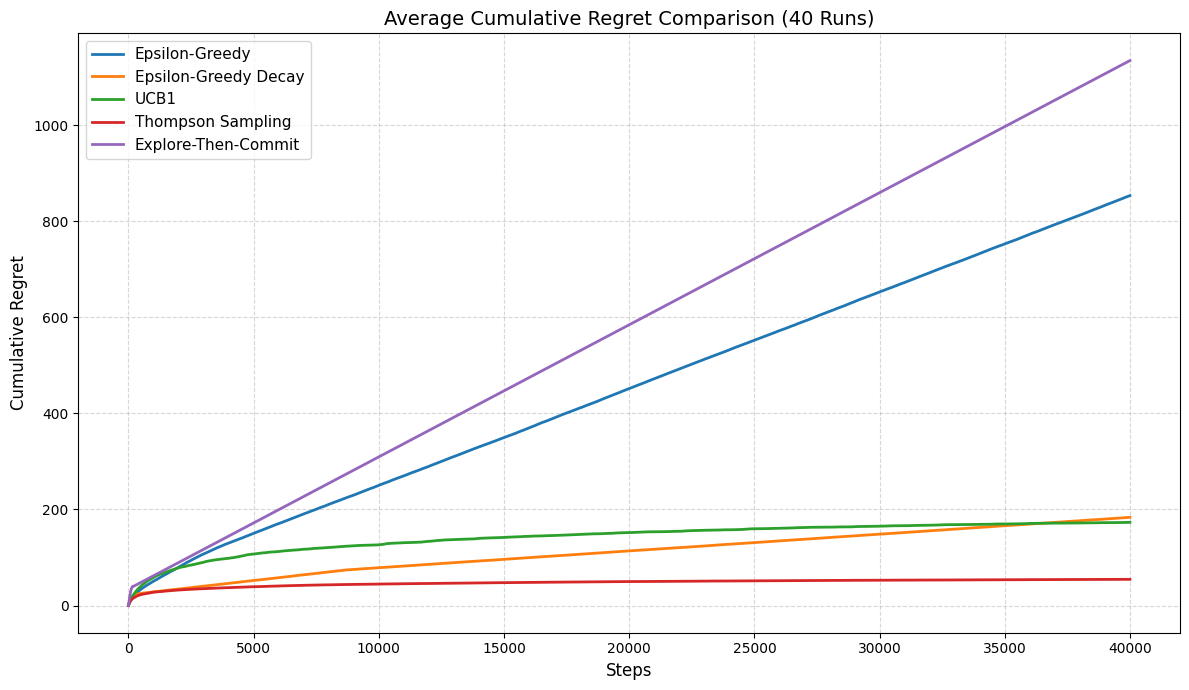

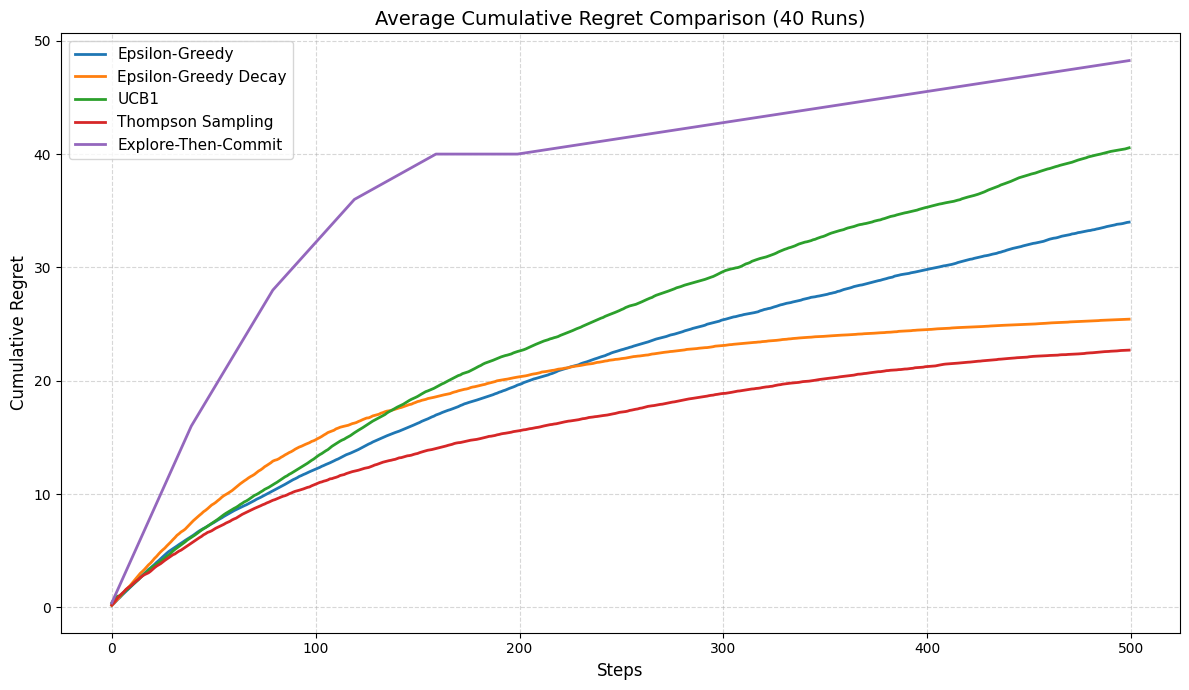

In [35]:
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
K = 5                                # Number of arms
means = [0.3, 0.4, 0.5, 0.6, 0.7]    # Bernoulli success probabilities for each arm
total_steps = 40000                  # Horizon (number of rounds per run)
num_runs = 40                        # Number of simulations to average over

# Hyperparameters for the algorithms
EPSILON = 0.1
EPSILON_START = 1.0
EPSILON_MIN = 0.005
DECAY_RATE = 0.99
ETC_M = 40                           # Explore-then-commit steps per arm (Total exploration = K * m)
SAMBA_ALPHA = 0.1
SAMBA_BETA = 2.0

# --- 2. BENCHMARKING FUNCTION ---
def run_experiment():
    # Dictionary to hold the raw regret histories for all 40 runs per algorithm
    # Format: { algorithm_name: list of lists (shape: 40 runs x total_steps) }
    raw_regrets = {
        "Epsilon-Greedy": [],
        "Epsilon-Greedy Decay": [],
        "UCB1": [],
        "Thompson Sampling": [],
        "Explore-Then-Commit": [],
        # "SAMBA": []
    }

    print(f"Running {num_runs} simulations for each algorithm...")

    for run in range(num_runs):
        # 1. Epsilon-Greedy
        env = Env(means, arm_algorithm='top')
        epsilon_greedy(K, total_steps, EPSILON, env)
        raw_regrets["Epsilon-Greedy"].append(np.cumsum(env.regret_history))

        # 2. Epsilon-Greedy Decay
        env = Env(means, arm_algorithm='top')
        # This function takes the pull_arm function pointer directly instead of the Env object
        epsilon_greedy_decay(K, total_steps, EPSILON_START, EPSILON_MIN, DECAY_RATE, env.pull_arm)
        raw_regrets["Epsilon-Greedy Decay"].append(np.cumsum(env.regret_history))

        # 3. UCB1
        env = Env(means, arm_algorithm='top')
        ucb1(K, total_steps, env)
        raw_regrets["UCB1"].append(np.cumsum(env.regret_history))

        # 4. Thompson Sampling
        env = Env(means, arm_algorithm='top')
        thompson_sampling_bernoulli(K, total_steps, env)
        raw_regrets["Thompson Sampling"].append(np.cumsum(env.regret_history))

        # 5. Explore-Then-Commit
        env = Env(means, arm_algorithm='top')
        explore_then_commit(K, total_steps, ETC_M, env)
        raw_regrets["Explore-Then-Commit"].append(np.cumsum(env.regret_history))

        # # 6. SAMBA
        # env = Env(means, arm_algorithm='top')
        # samba(K, total_steps, SAMBA_ALPHA, SAMBA_BETA, env)
        # raw_regrets["SAMBA"].append(np.cumsum(env.regret_history))

    # --- 3. AVERAGE THE RESULTS ---
    averaged_regrets = {}
    for algo_name, regrets_list in raw_regrets.items():
        # Convert lists to a 2D numpy array and average across rows (axis=0)
        averaged_regrets[algo_name] = np.mean(regrets_list, axis=0)
        
    return averaged_regrets

# Run the simulations
averaged_results = run_experiment()

# --- 4. PLOT THE CUMULATIVE REGRET ---
plt.figure(figsize=(12, 7))

for algo_name, avg_regret in averaged_results.items():
    plt.plot(avg_regret, label=algo_name, linewidth=2)

plt.title(f"Average Cumulative Regret Comparison ({num_runs} Runs)", fontsize=14)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Cumulative Regret", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()

# Render the plot
plt.show()

# --- 5. PLOT THE CUMULATIVE REGRET FOR ROUNDS UP TO 500 ---
plt.figure(figsize=(12, 7))

for algo_name, avg_regret in averaged_results.items():
    plt.plot(avg_regret[:500], label=algo_name, linewidth=2)

plt.title(f"Average Cumulative Regret Comparison ({num_runs} Runs)", fontsize=14)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Cumulative Regret", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()

# Render the plot
plt.show()

In [ ]:
def RunSPSAMF():
    pass